In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 파생변수 추가 버전 데이터
type1_df = pd.read_csv('../../data/df_type1_파생변수추가.csv')
type1_df.columns = type1_df.columns.str.strip()

NEW_DERIVED = [
    'clamp_per_press', 'temp_diff',
    'press_time_ratio', 'spray_cycle_ratio', 'heat_index'
    
]

print(f"Shape: {type1_df.shape}")
print(f"\n신규 파생변수: {NEW_DERIVED}")
print(f"\n컬럼 수: 원본 25 → 파생변수 추가 {type1_df.shape[1]}")

Shape: (2651, 33)

신규 파생변수: ['clamp_per_press', 'temp_diff', 'press_time_ratio', 'spray_cycle_ratio', 'heat_index']

컬럼 수: 원본 25 → 파생변수 추가 33


In [2]:
type1_df.columns

Index(['id', 'Product_Type', 'Shot', 'Velocity_1', 'Velocity_2', 'Velocity_3',
       'High_Velocity', 'Cylinder_Pressure', 'Rapid_Rise_Time',
       'Biscuit_Thickness', 'Clamping_Force', 'Cycle_Time',
       'Pressure_Rise_Time', 'Casting_Pressure', 'Spray_Time', 'Spray_1_Time',
       'Spray_2_Time', 'Melting_Furnace_Temp', 'Air_Pressure', 'Coolant_Temp',
       'Coolant_Pressure', 'Factory_Temp', 'Factory_Humidity',
       'Pressure_Diff_ratio', 'clamp_per_press', 'temp_diff',
       'press_time_ratio', 'spray_cycle_ratio', 'heat_index', 'vel_accel',
       'vel_ratio', 'Defect_Status', 'Defect_Type'],
      dtype='str')

In [3]:
type1_df.head()

,id,Product_Type,Shot,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Cylinder_Pressure,Rapid_Rise_Time,Biscuit_Thickness,...,Pressure_Diff_ratio,clamp_per_press,temp_diff,press_time_ratio,spray_cycle_ratio,heat_index,vel_accel,vel_ratio,Defect_Status,Defect_Type
0,1,1,1,0.144,0.170,0.188,2.134,214,0.008,10,...,4.845794,0.248795,662.1,5.500,0.376812,19.2136,0.026,1.105882,0,Normal
1,1002,1,2,0.144,0.170,0.182,2.124,217,0.008,11,...,4.847926,0.244297,663.5,5.500,0.376812,19.1478,0.026,1.070588,0,Normal
2,2003,1,3,0.144,0.170,0.182,2.116,214,0.008,11,...,4.845794,0.247830,663.5,5.125,0.375000,19.1478,0.026,1.070588,0,Normal
3,3004,1,4,0.144,0.170,0.182,2.137,217,0.008,11,...,4.843318,0.244529,663.5,5.375,0.376812,19.1478,0.026,1.070588,1,Exfoliation
4,4005,1,5,0.144,0.172,0.176,2.111,217,0.008,12,...,4.847926,0.244297,665.0,5.250,0.376812,19.0162,0.028,1.023256,0,Normal


In [4]:
cols = ['Velocity_1', 'Velocity_2', 'Velocity_3', 'High_Velocity']
type1_df['Velocity_minmax'] = type1_df[cols].max(axis=1) - type1_df[cols].min(axis=1)

In [5]:
display(type1_df[['Velocity_minmax']].head()) 
display(type1_df[['Velocity_minmax']].tail())

,Velocity_minmax
0,1.990
1,1.980
2,1.972
3,1.993
4,1.967


,Velocity_minmax
2646,2.049
2647,2.070
2648,2.111
2649,2.086
2650,2.078


In [6]:
# 파생변수는 CSV에 이미 포함 — 추가 계산 불필요
# 기존 통계 노트북 호환용 변수 정의만 유지
type1_df['Pressure_Diff_ratio'] = type1_df['Casting_Pressure'] / type1_df['Cylinder_Pressure']
print("✅ 데이터 로드 완료 (파생변수 이미 포함)")

✅ 데이터 로드 완료 (파생변수 이미 포함)


In [7]:
type1_df.columns

Index(['id', 'Product_Type', 'Shot', 'Velocity_1', 'Velocity_2', 'Velocity_3',
       'High_Velocity', 'Cylinder_Pressure', 'Rapid_Rise_Time',
       'Biscuit_Thickness', 'Clamping_Force', 'Cycle_Time',
       'Pressure_Rise_Time', 'Casting_Pressure', 'Spray_Time', 'Spray_1_Time',
       'Spray_2_Time', 'Melting_Furnace_Temp', 'Air_Pressure', 'Coolant_Temp',
       'Coolant_Pressure', 'Factory_Temp', 'Factory_Humidity',
       'Pressure_Diff_ratio', 'clamp_per_press', 'temp_diff',
       'press_time_ratio', 'spray_cycle_ratio', 'heat_index', 'vel_accel',
       'vel_ratio', 'Defect_Status', 'Defect_Type', 'Velocity_minmax'],
      dtype='str')

In [8]:
type1_df.columns = type1_df.columns.str.strip()

In [9]:
type1_df.describe()

,id,Product_Type,Shot,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Cylinder_Pressure,Rapid_Rise_Time,Biscuit_Thickness,...,Pressure_Diff_ratio,clamp_per_press,temp_diff,press_time_ratio,spray_cycle_ratio,heat_index,vel_accel,vel_ratio,Defect_Status,Velocity_minmax
count,2.651000e+03,2651.0,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,...,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000,2651.000000
mean,1.780173e+06,1.0,545.038853,0.143149,0.168794,0.182202,2.137356,219.160694,0.008046,11.648435,...,4.840048,0.241603,666.395285,5.295801,0.390399,19.419921,0.025645,1.079516,0.217276,1.994207
std,1.259517e+06,0.0,356.391019,0.003804,0.004702,0.006395,0.043195,7.472050,0.001414,1.396538,...,0.008107,0.008020,14.025515,0.768637,0.019727,1.635957,0.002787,0.026523,0.412470,0.041885
min,1.000000e+00,1.0,1.000000,0.134000,0.162000,0.172000,1.247000,214.000000,0.005000,0.000000,...,4.748954,0.215035,637.300000,2.047619,0.045665,16.668000,0.018000,1.011628,0.000000,1.107000
25%,6.631695e+05,1.0,229.000000,0.142000,0.168000,0.178000,2.122000,215.000000,0.008000,11.000000,...,4.834482,0.241445,655.800000,5.125000,0.381643,17.955000,0.024000,1.059524,0.000000,1.979000
50%,1.551227e+06,1.0,516.000000,0.142000,0.168000,0.182000,2.137000,217.000000,0.008000,12.000000,...,4.841004,0.244231,666.200000,5.375000,0.384615,19.936000,0.026000,1.082353,0.000000,1.995000
75%,2.877004e+06,1.0,842.000000,0.144000,0.170000,0.185000,2.153000,218.000000,0.008000,12.000000,...,4.845794,0.245902,675.900000,5.500000,0.391509,20.399000,0.027000,1.096386,0.000000,2.010000
max,4.205745e+06,1.0,1296.000000,0.180000,0.212000,0.234000,2.285000,241.000000,0.021000,22.000000,...,4.935897,0.253128,699.300000,9.200000,0.459574,22.624000,0.046000,1.151515,1.000000,2.127000


In [10]:
type1_df[['Casting_Pressure','Cylinder_Pressure']].describe()

,Casting_Pressure,Cylinder_Pressure
count,2651.000000,2651.000000
mean,1060.742361,219.160694
std,36.035533,7.472050
min,1034.000000,214.000000
25%,1039.000000,215.000000
50%,1052.000000,217.000000
75%,1055.000000,218.000000
max,1164.000000,241.000000


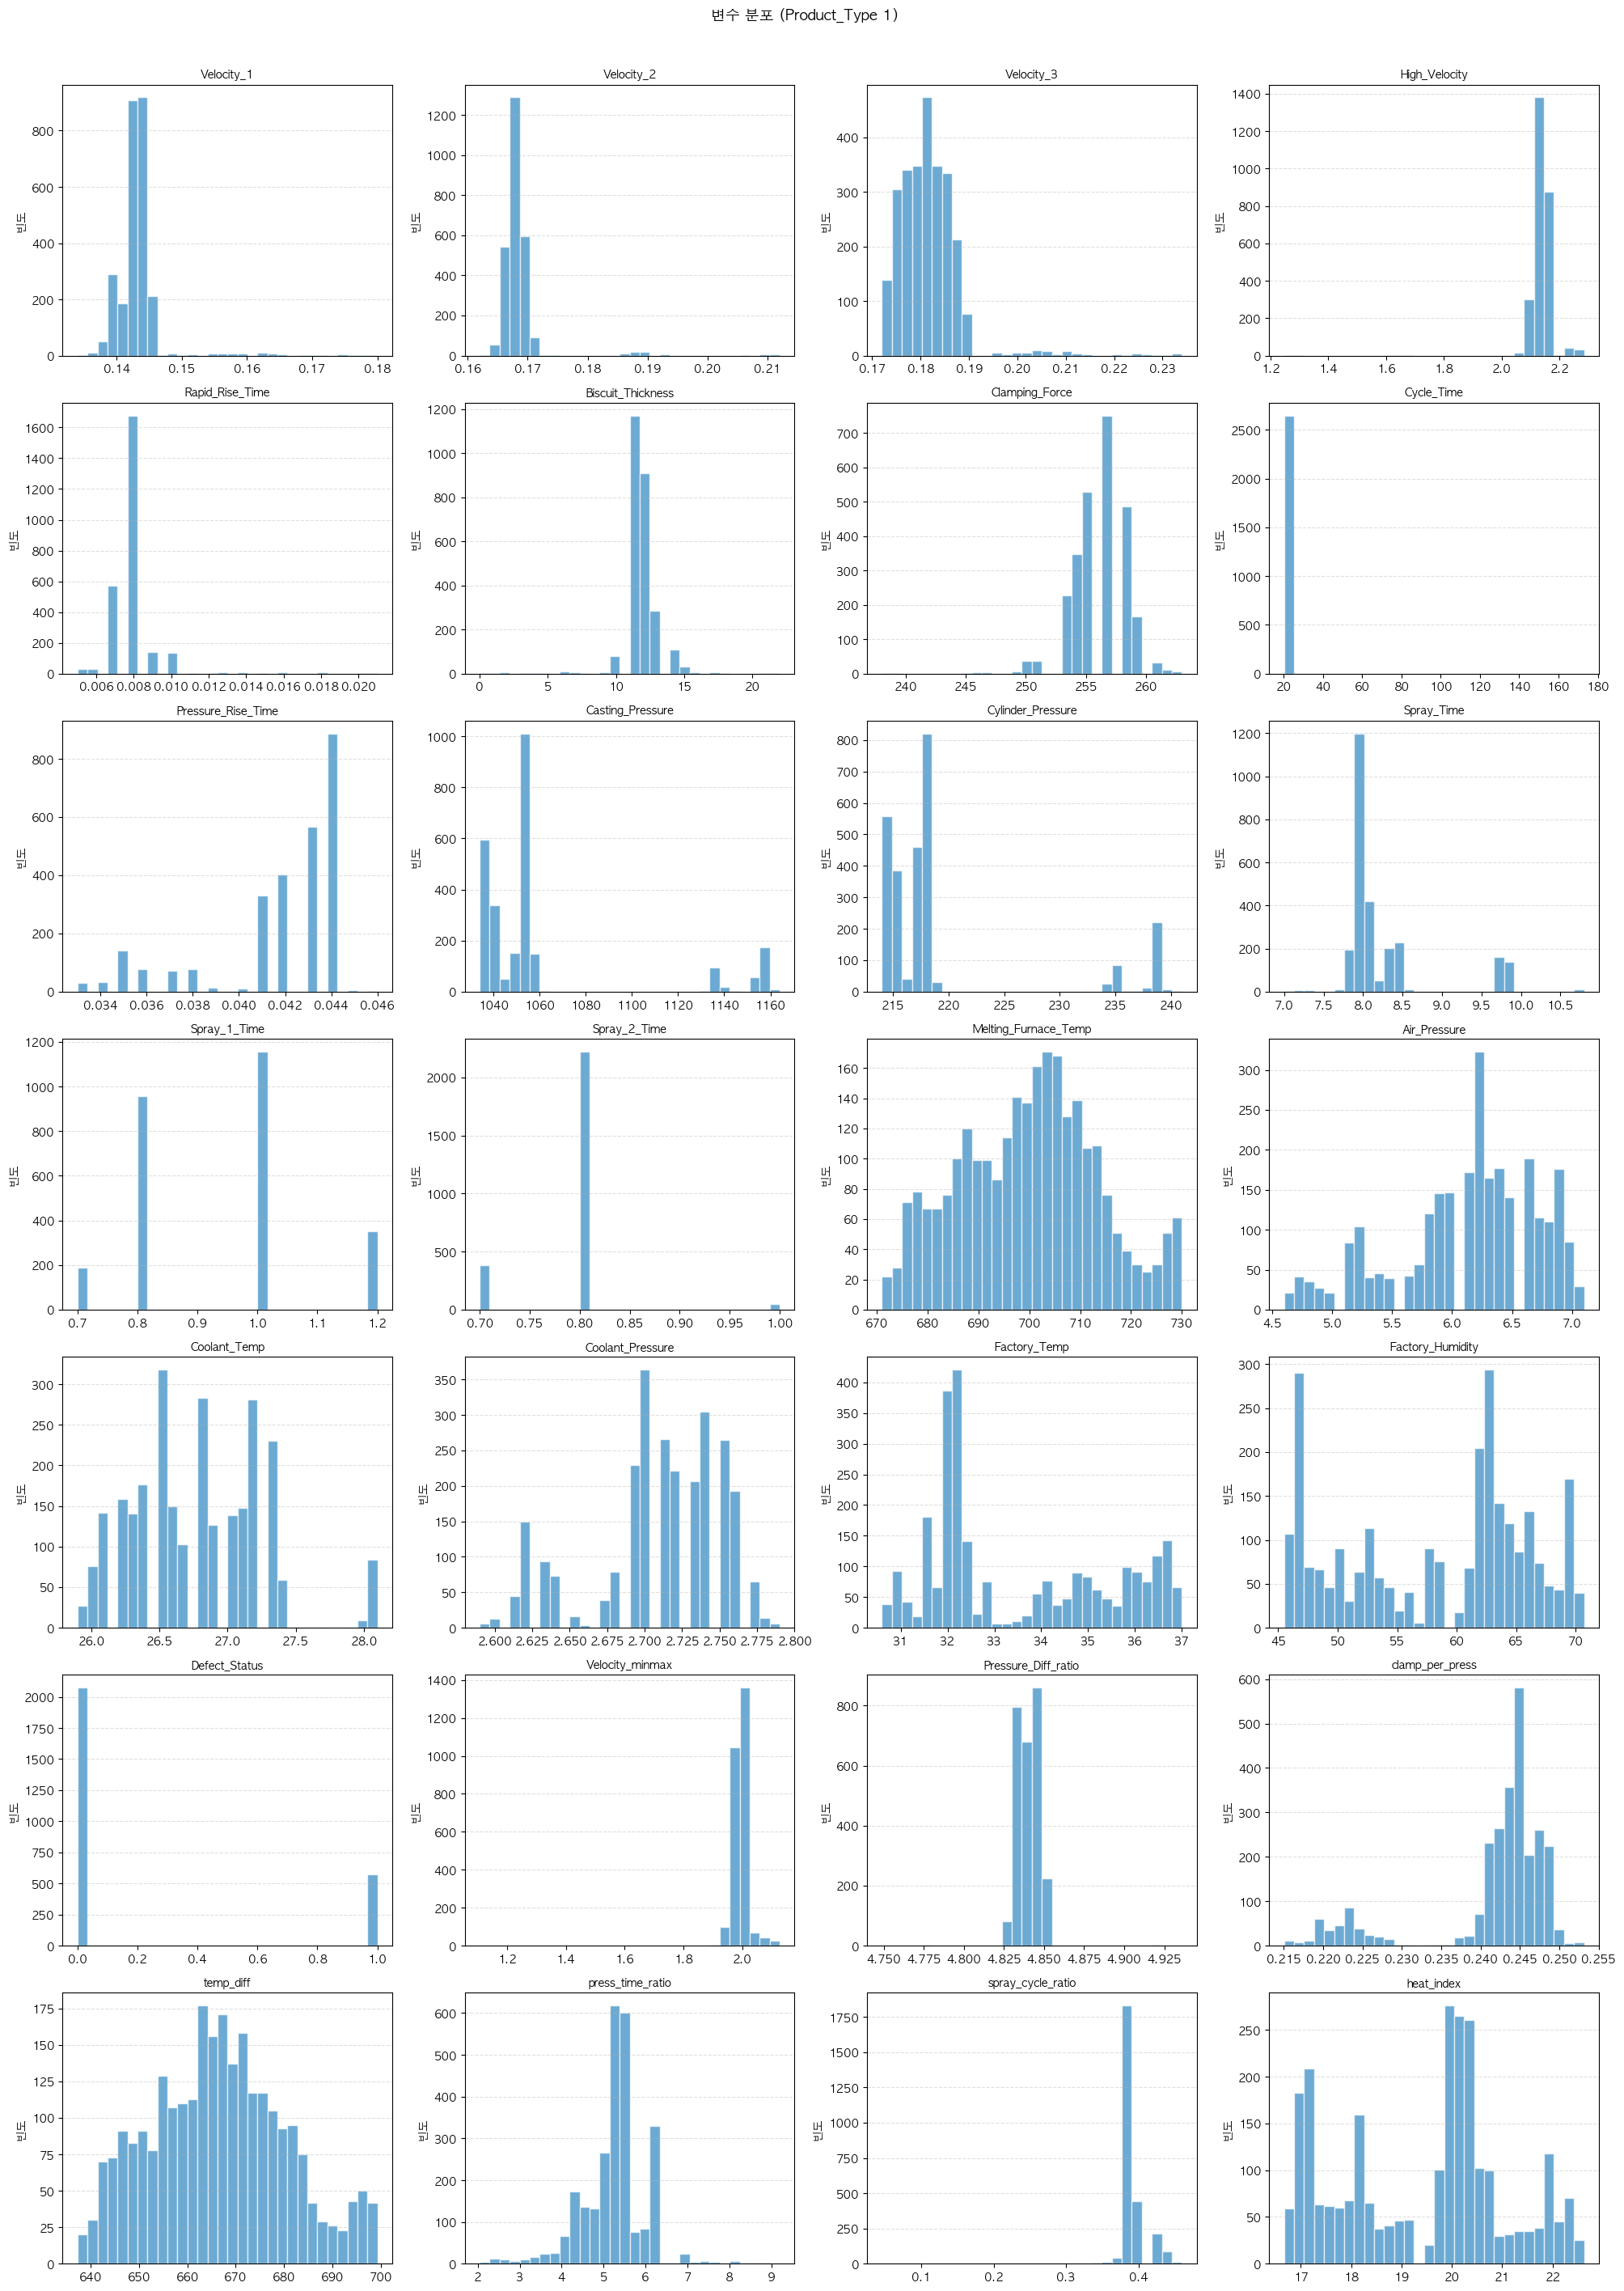

In [11]:
import math

final_vars = [
    'Velocity_1', 
    'Velocity_2', 
    'Velocity_3',
    'High_Velocity', 
    'Rapid_Rise_Time',
    'Biscuit_Thickness', 
    'Clamping_Force', 
    'Cycle_Time',
    'Pressure_Rise_Time', 
    'Casting_Pressure',
    'Cylinder_Pressure', 
    'Spray_Time', 
    'Spray_1_Time',
    'Spray_2_Time', 
    'Melting_Furnace_Temp', 
    'Air_Pressure', 
    'Coolant_Temp',
    'Coolant_Pressure', 
    'Factory_Temp', 
    'Factory_Humidity', 
    'Defect_Status', 
    'Defect_Type', 
    'Velocity_minmax', 
    'Pressure_Diff_ratio',
    'clamp_per_press', 
    'temp_diff',
    'press_time_ratio', 
    'spray_cycle_ratio', 
    'heat_index'
]
# 변수 히스토그램
num_cols = [col for col in final_vars if type1_df[col].dtype in ['int64', 'float64']]

n_cols = 4
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(type1_df[col].dropna(), bins=30, color='#2E86C1', alpha=0.7, edgecolor='white')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('빈도')
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('변수 분포 (Product_Type 1)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

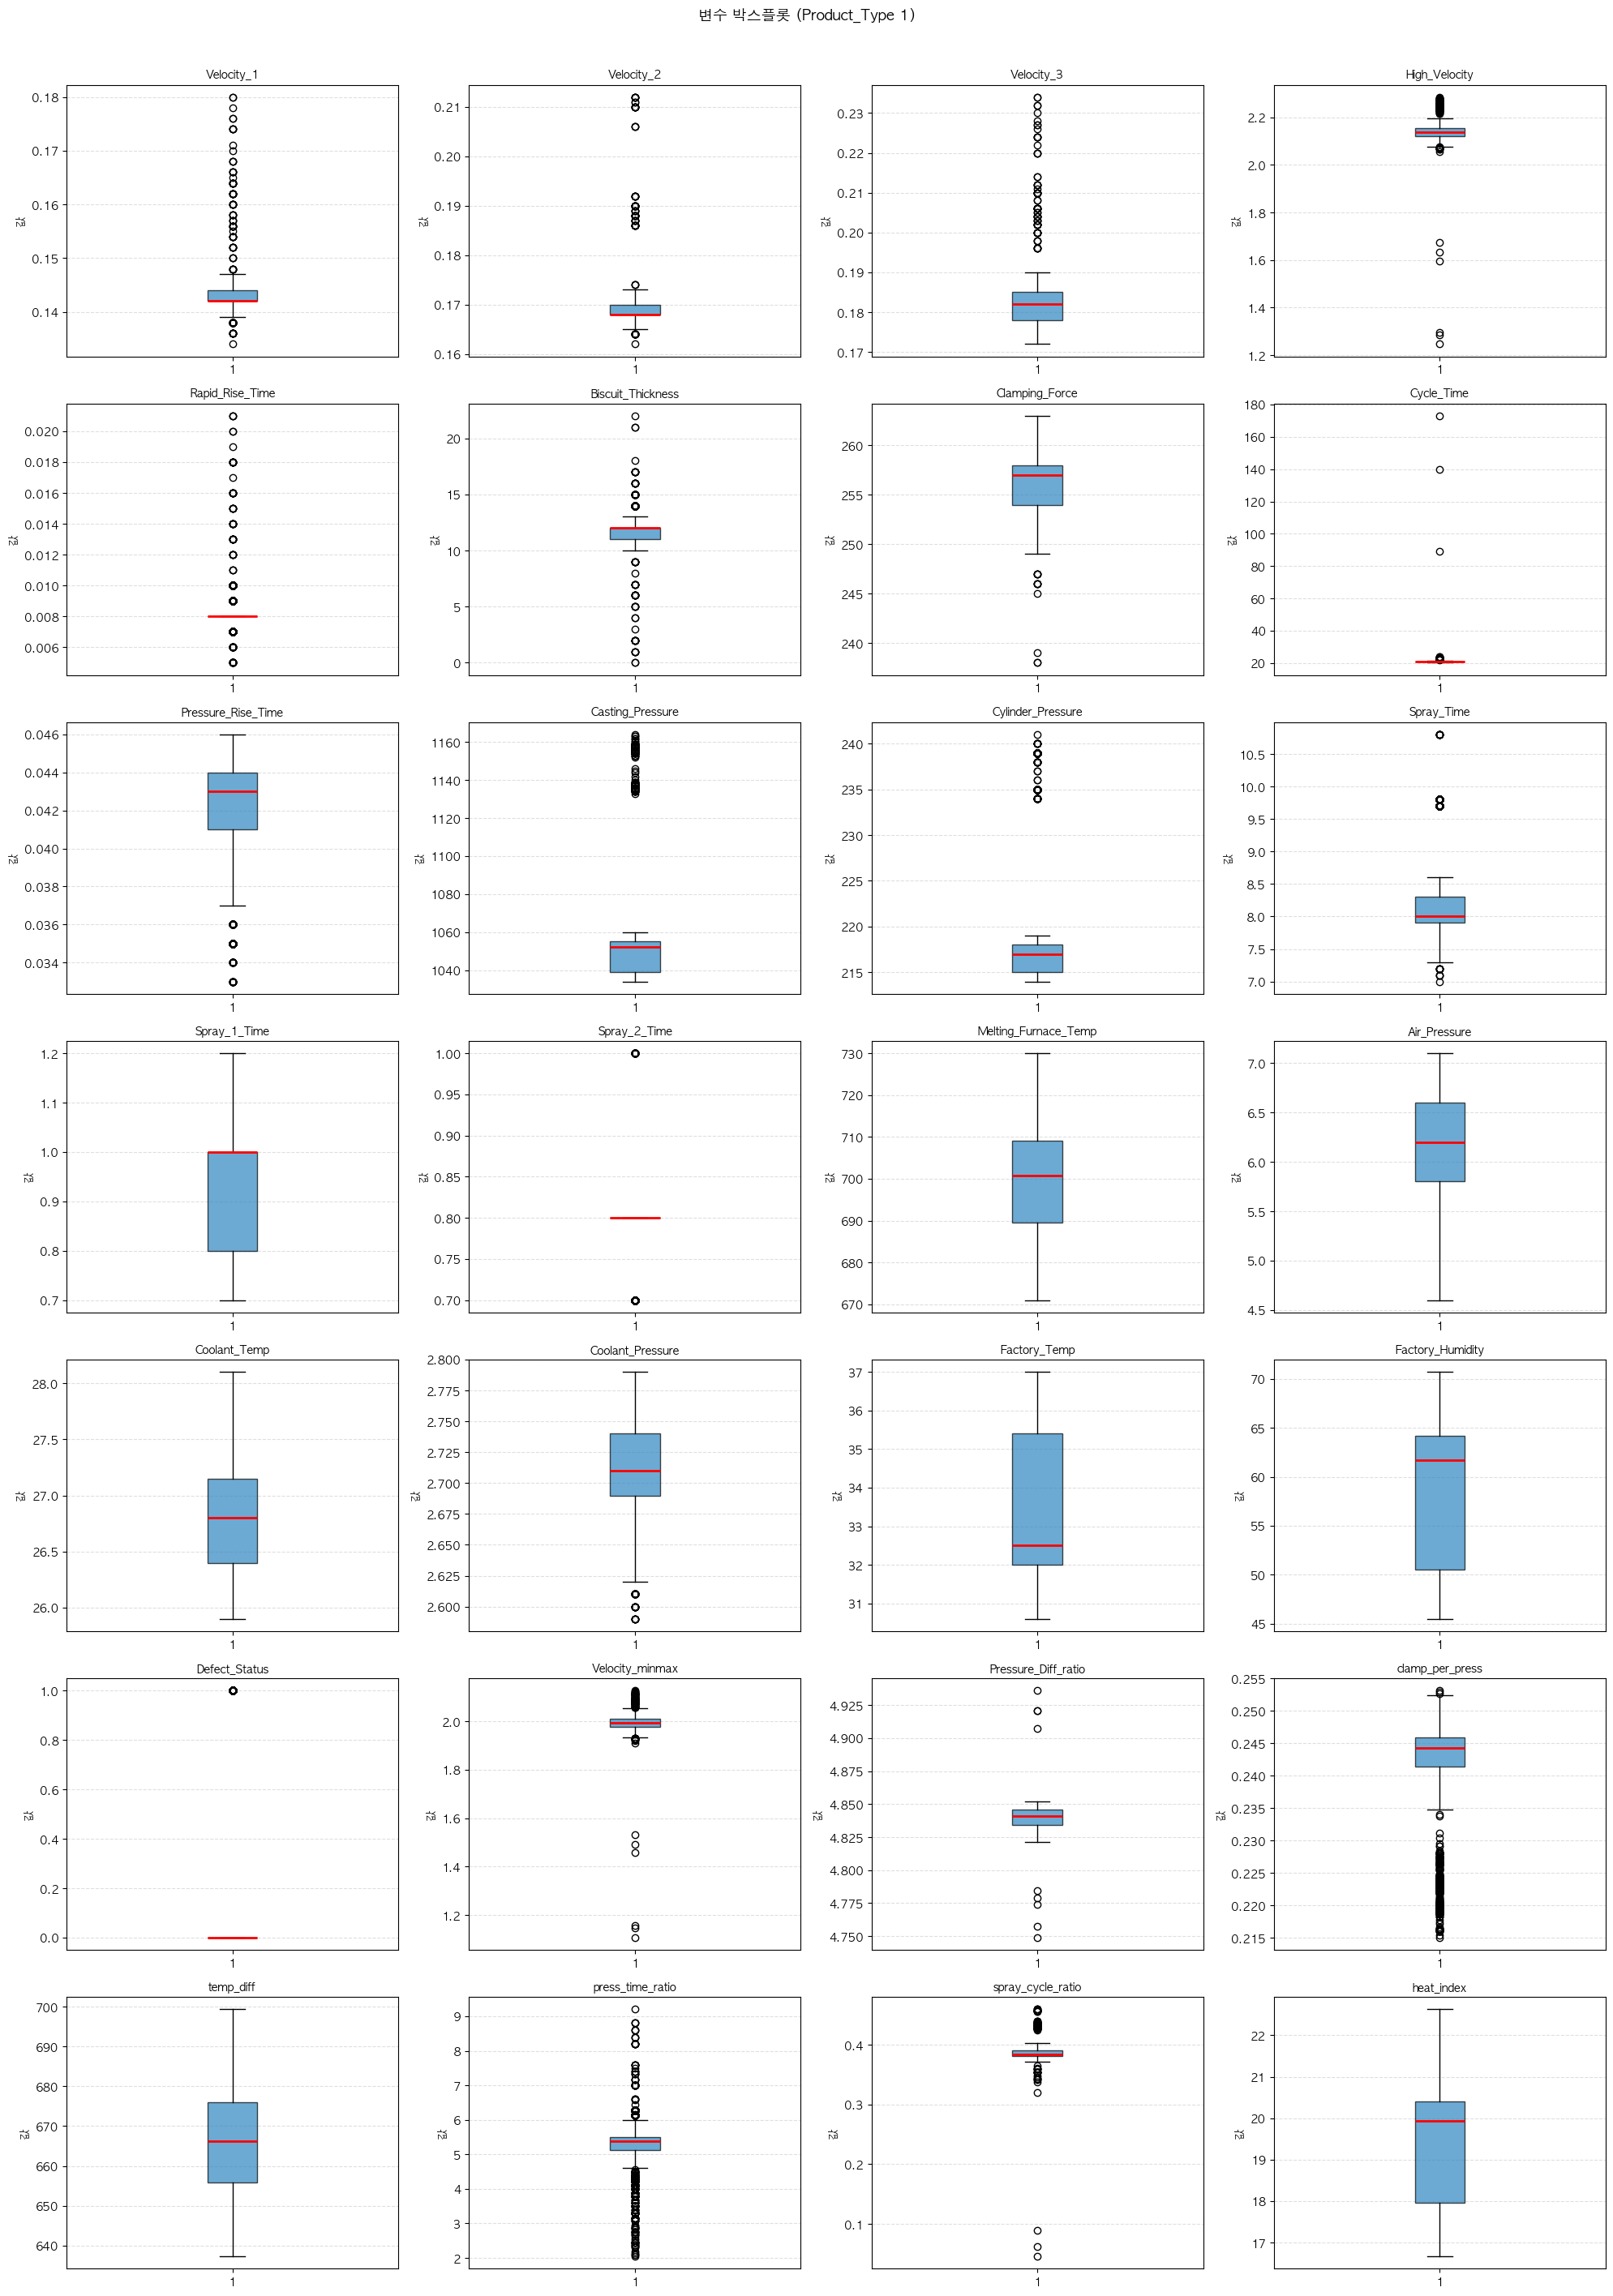

In [12]:
# 변수 박스플롯
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(type1_df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#2E86C1', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('값')
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('변수 박스플롯 (Product_Type 1)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

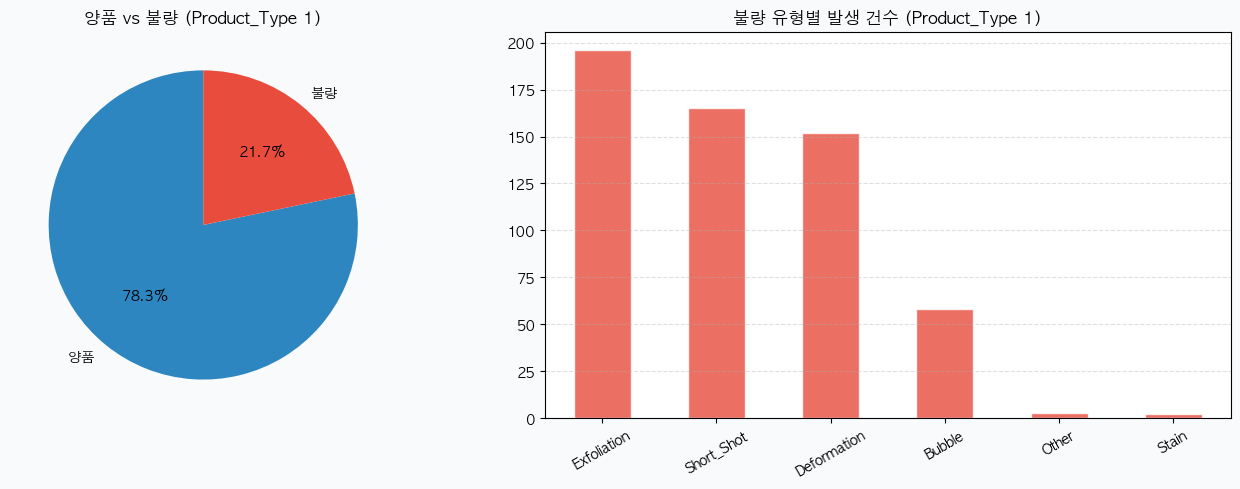

In [13]:
# 불량 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#F8FAFB')

# 파이 차트
sizes = type1_df['Defect_Status'].value_counts().sort_index()
axes[0].pie(sizes, labels=['양품', '불량'], autopct='%1.1f%%',
            colors=['#2E86C1', '#E74C3C'], startangle=90)
axes[0].set_title(f'양품 vs 불량 (Product_Type 1)', fontweight='bold')

# 불량 유형 바 차트
defect_counts = type1_df[type1_df['Defect_Status']==1]['Defect_Type'].value_counts()
defect_counts.plot(kind='bar', ax=axes[1], color='#E74C3C', alpha=0.8, edgecolor='white')
axes[1].set_title('불량 유형별 발생 건수 (Product_Type 1)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [14]:
from scipy.stats import spearmanr

exclude_cols = ['Defect_Status', 'Defect_Type', 'id', 'Product_Type', 'Shot',
                'Velocity_minmax', 'Velocity_diff_1_2', 'Velocity_diff_2_3', 'Velocity_diff_3_high','vel_accel', 'vel_ratio']

results = []
for col in type1_df.columns:
    if col in exclude_cols:
        continue
    if type1_df[col].dtype not in ['int64', 'float64']:
        continue
    clean = type1_df[[col, 'Defect_Status']].dropna()
    corr, p = spearmanr(clean[col], clean['Defect_Status'])
    results.append({
        '변수': col,
        '스피어만 상관계수': round(corr, 4),
        'p-value': round(p, 4),
        '절댓값': round(abs(corr), 4),
        '신규': '🆕' if col in NEW_DERIVED else ''
    })

spearman_df = pd.DataFrame(results).sort_values('절댓값', ascending=False)
spearman_df.insert(0, 'rank', range(1, len(spearman_df)+1))
spearman_df = spearman_df.set_index('rank')
display(spearman_df)

,변수,스피어만 상관계수,p-value,절댓값,신규
rank,,,,,
1,heat_index,-0.3082,0.0000,0.3082,🆕
2,Factory_Humidity,-0.2782,0.0000,0.2782,
3,Factory_Temp,0.2155,0.0000,0.2155,
4,Biscuit_Thickness,-0.1698,0.0000,0.1698,
5,clamp_per_press,0.1671,0.0000,0.1671,🆕
6,Spray_2_Time,0.1669,0.0000,0.1669,
7,Casting_Pressure,-0.1252,0.0000,0.1252,
8,Cylinder_Pressure,-0.1207,0.0000,0.1207,
9,Cycle_Time,-0.1204,0.0000,0.1204,


In [15]:
high_corr_vars = ['Casting_Pressure', 'Cylinder_Pressure', 'Pressure_Diff_ratio']
print("[ 다중공선성 의심 변수 상관관계 ]")
display(type1_df[high_corr_vars].corr().round(3))
print()
print("※ 상관계수 0.99 → 셋 중 Pressure_Diff(파생변수)만 유지 권장")
print("  Pressure_Diff = Casting_Pressure - Cylinder_Pressure")
print("  → 두 압력의 차이가 실질적인 정보를 담고 있음")

[ 다중공선성 의심 변수 상관관계 ]


,Casting_Pressure,Cylinder_Pressure,Pressure_Diff_ratio
Casting_Pressure,1.000,0.999,-0.048
Cylinder_Pressure,0.999,1.000,-0.097
Pressure_Diff_ratio,-0.048,-0.097,1.000



※ 상관계수 0.99 → 셋 중 Pressure_Diff(파생변수)만 유지 권장
  Pressure_Diff = Casting_Pressure - Cylinder_Pressure
  → 두 압력의 차이가 실질적인 정보를 담고 있음


In [16]:
top10 = spearman_df.head(10).copy()

print("🏆 TOP 10 변수 (상관계수 기준)")
print("-" * 50)

for idx, row in top10.iterrows():   # idx가 rank 인덱스
    direction = "▼ 불량 감소" if row['스피어만 상관계수'] < 0 else "▲ 불량 증가"
    print(f"  #{int(idx):2d}  {row['변수']:<25}  {row['스피어만 상관계수']:+.4f}  {direction}")

🏆 TOP 10 변수 (상관계수 기준)
--------------------------------------------------
  # 1  heat_index                 -0.3082  ▼ 불량 감소
  # 2  Factory_Humidity           -0.2782  ▼ 불량 감소
  # 3  Factory_Temp               +0.2155  ▲ 불량 증가
  # 4  Biscuit_Thickness          -0.1698  ▼ 불량 감소
  # 5  clamp_per_press            +0.1671  ▲ 불량 증가
  # 6  Spray_2_Time               +0.1669  ▲ 불량 증가
  # 7  Casting_Pressure           -0.1252  ▼ 불량 감소
  # 8  Cylinder_Pressure          -0.1207  ▼ 불량 감소
  # 9  Cycle_Time                 -0.1204  ▼ 불량 감소
  #10  temp_diff                  -0.1065  ▼ 불량 감소


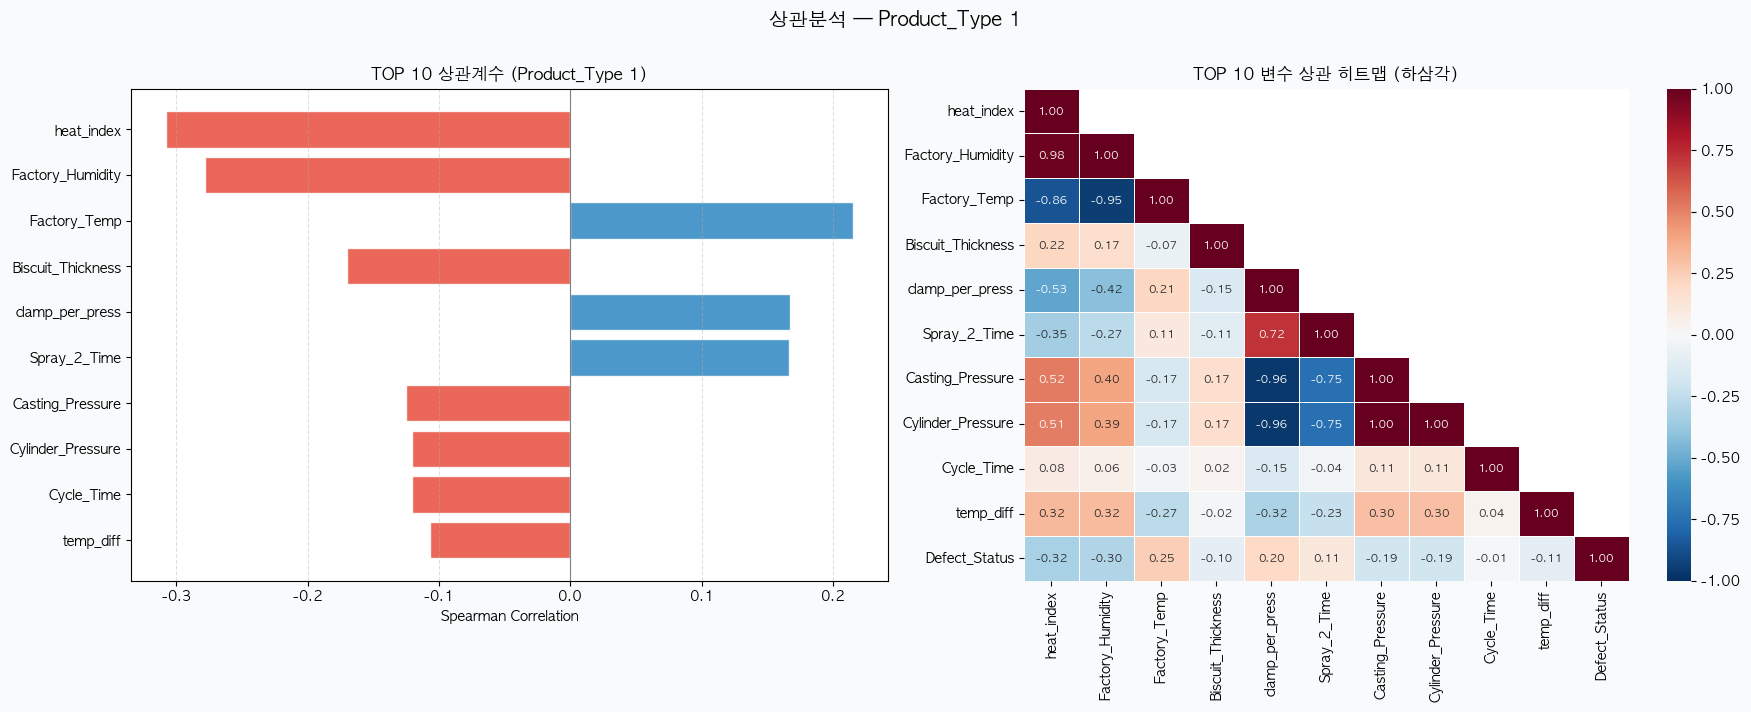

In [17]:
import numpy as np
# 상관계수 시각화
fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor='#F8FAFB')

# 바 차트
colors = ['#E74C3C' if v < 0 else '#2E86C1' for v in top10['스피어만 상관계수']]
axes[0].barh(top10['변수'][::-1], top10['스피어만 상관계수'][::-1],
             color=colors[::-1], alpha=0.85, edgecolor='white')
axes[0].axvline(0, color='gray', lw=0.8)
axes[0].set_title('TOP 10 상관계수 (Product_Type 1)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Spearman Correlation')
axes[0].grid(axis='x', linestyle='--', alpha=0.4)

# 히트맵
top10_vars = top10['변수'].tolist()
corr_matrix = type1_df[top10_vars + ['Defect_Status']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, ax=axes[1], annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot_kws={'size': 8}, linewidths=0.5)
axes[1].set_title('TOP 10 변수 상관 히트맵 (하삼각)', fontsize=12, fontweight='bold')

plt.suptitle('상관분석 — Product_Type 1', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [18]:
from scipy import stats

# 원본 변수 + 신규 파생변수 포함
target_vars = [
    'Velocity_1', 'Velocity_2', 'Velocity_3', 'High_Velocity',
    'Rapid_Rise_Time', 'Biscuit_Thickness', 'Clamping_Force', 'Cycle_Time',
    'Pressure_Rise_Time', 'Casting_Pressure', 'Cylinder_Pressure',
    'Spray_Time', 'Spray_1_Time', 'Spray_2_Time',
    'Melting_Furnace_Temp', 'Air_Pressure', 'Coolant_Temp', 'Coolant_Pressure',
    'Factory_Temp', 'Factory_Humidity',
    'Pressure_Diff_ratio',
    # 신규 파생변수
    'clamp_per_press', 'temp_diff',
    'press_time_ratio', 'spray_cycle_ratio', 'heat_index'    
]

results = []
for col in target_vars:
    valid = type1_df[[col, 'Defect_Status']].dropna()
    stat, p = stats.shapiro(valid[col])
    results.append({
        '변수': col,
        'W통계량': round(stat, 4),
        'p-value': round(p, 4),
        '정규성': '✅' if p > 0.05 else '❌',
        '신규': '🆕' if col in NEW_DERIVED else ''
    })

display(pd.DataFrame(results))

,변수,W통계량,p-value,정규성,신규
0,Velocity_1,0.5795,0.0,❌,
1,Velocity_2,0.4157,0.0,❌,
2,Velocity_3,0.7624,0.0,❌,
3,High_Velocity,0.4807,0.0,❌,
4,Rapid_Rise_Time,0.5515,0.0,❌,
5,Biscuit_Thickness,0.7065,0.0,❌,
6,Clamping_Force,0.9128,0.0,❌,
7,Cycle_Time,0.0542,0.0,❌,
8,Pressure_Rise_Time,0.7596,0.0,❌,
9,Casting_Pressure,0.5897,0.0,❌,


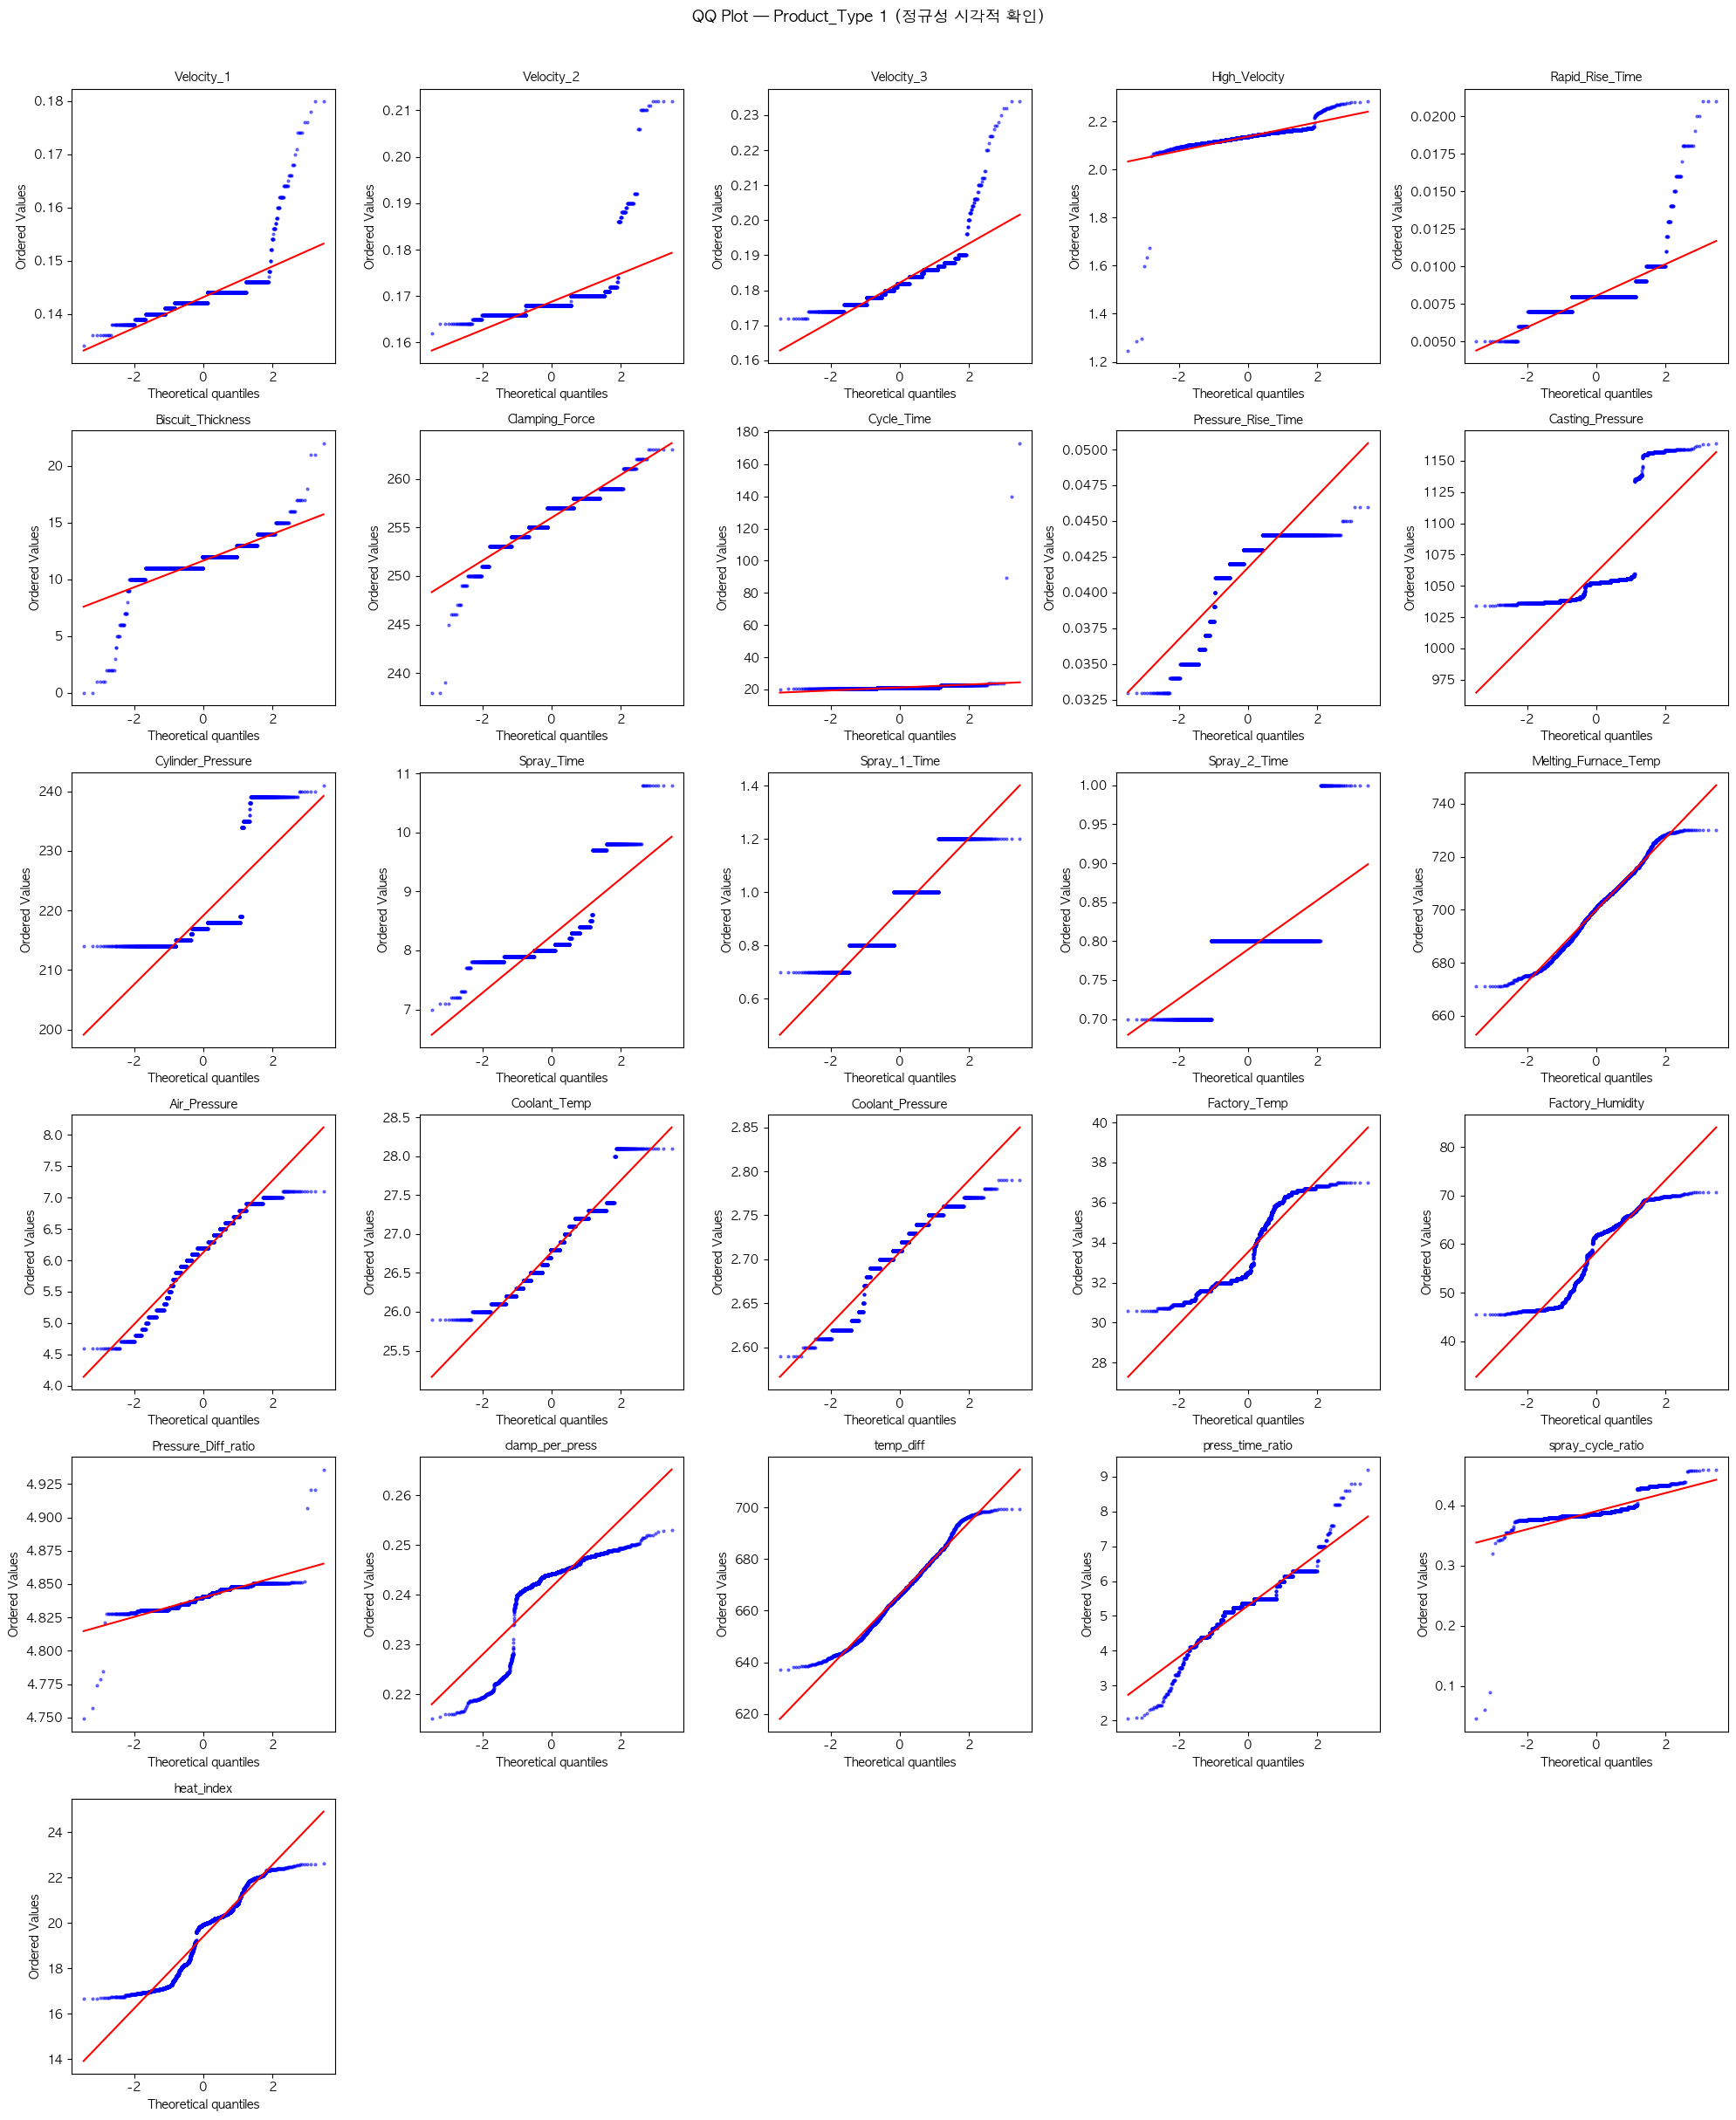

In [19]:
#---------------------
# 1-2. QQ Plot
#---------------------

import scipy.stats as stats
import matplotlib.pyplot as plt
import math

n_vars = len(target_vars)
n_cols = 5
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(target_vars):
    stats.probplot(type1_df[col].dropna(), dist="norm", plot=axes[i])
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].get_lines()[0].set(markersize=2, alpha=0.5)

# 남는 빈 서브플롯 숨기기
for j in range(n_vars, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('QQ Plot — Product_Type 1 (정규성 시각적 확인)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [20]:
#---------------------
# 2. Mann-Whitney U 검정
#---------------------

from scipy.stats import mannwhitneyu

defect   = type1_df[type1_df['Defect_Status'] == 1]
normal   = type1_df[type1_df['Defect_Status'] == 0]

results = []
for col in target_vars:
    stat, p = mannwhitneyu(
        defect[col].dropna(),
        normal[col].dropna(),
        alternative='two-sided'
    )
    results.append({
        '변수': col,
        'U통계량': round(stat, 1),
        'p-value': round(p, 4),
        '유의성': '✅' if p < 0.05 else '❌'
    })

result_df = pd.DataFrame(results).sort_values('p-value')
#print(result_df.to_string(index=False))
display(pd.DataFrame(results))

,변수,U통계량,p-value,유의성
0,Velocity_1,616684.5,0.2201,❌
1,Velocity_2,565772.5,0.0353,✅
2,Velocity_3,575010.0,0.1622,❌
3,High_Velocity,658197.0,0.0002,✅
4,Rapid_Rise_Time,624281.5,0.0557,❌
5,Biscuit_Thickness,464947.0,0.0000,✅
6,Clamping_Force,662913.5,0.0000,✅
7,Cycle_Time,498077.5,0.0000,✅
8,Pressure_Rise_Time,678225.5,0.0000,✅
9,Casting_Pressure,493113.0,0.0000,✅


In [21]:
#---------------------
# 3. 효과크기 계산 (Rank-Biserial Correlation)
#---------------------

from scipy.stats import mannwhitneyu
import numpy as np

def rank_biserial(u_stat, n1, n2):
    return (2 * u_stat) / (n1 * n2) - 1

defect = type1_df[type1_df['Defect_Status'] == 1]
normal = type1_df[type1_df['Defect_Status'] == 0]
n1, n2 = len(defect), len(normal)

results = []
for col in target_vars:
    stat, p = mannwhitneyu(defect[col].dropna(), normal[col].dropna(), alternative='two-sided')
    r = abs(rank_biserial(stat, n1, n2))
    results.append({
        '변수': col,
        'p-value': round(p, 4),
        '효과크기(r)': round(r, 4),
        '해석': '대' if r >= 0.5 else '중' if r >= 0.3 else '소'
    })

result_df = pd.DataFrame(results).sort_values('효과크기(r)', ascending=False)
display(pd.DataFrame(results))

,변수,p-value,효과크기(r),해석
0,Velocity_1,0.2201,0.0319,소
1,Velocity_2,0.0353,0.0533,소
2,Velocity_3,0.1622,0.0378,소
3,High_Velocity,0.0002,0.1014,소
4,Rapid_Rise_Time,0.0557,0.0446,소
5,Biscuit_Thickness,0.0000,0.2220,소
6,Clamping_Force,0.0000,0.1093,소
7,Cycle_Time,0.0000,0.1665,소
8,Pressure_Rise_Time,0.0000,0.1349,소
9,Casting_Pressure,0.0000,0.1748,소


In [22]:
#-------------------------------------------
# 4. Kruskal-Wallis H 검정 (Defect_Type별 차이
#-------------------------------------------

from scipy.stats import kruskal

defect_types = ['Exfoliation', 'Short_Shot', 'Deformation', 'Bubble', 'Normal']

results = []
for col in target_vars:
    groups = [type1_df[type1_df['Defect_Type'] == dt][col].dropna() for dt in defect_types]
    stat, p = kruskal(*groups)
    results.append({
        '변수': col,
        'H통계량': round(stat, 2),
        'p-value': round(p, 4),
        '유의성': '✅' if p < 0.05 else '❌'
    })

result_df = pd.DataFrame(results).sort_values('p-value')
display(pd.DataFrame(results))

,변수,H통계량,p-value,유의성
0,Velocity_1,5.80,0.2143,❌
1,Velocity_2,9.23,0.0556,❌
2,Velocity_3,5.54,0.2364,❌
3,High_Velocity,22.03,0.0002,✅
4,Rapid_Rise_Time,6.04,0.1963,❌
5,Biscuit_Thickness,76.21,0.0000,✅
6,Clamping_Force,20.38,0.0004,✅
7,Cycle_Time,44.95,0.0000,✅
8,Pressure_Rise_Time,30.06,0.0000,✅
9,Casting_Pressure,44.12,0.0000,✅


In [23]:
#---------------------
# 5. 효과크기 계산 (Epsilon-squared)
#---------------------

from scipy.stats import kruskal

defect_types = ['Exfoliation', 'Short_Shot', 'Deformation', 'Bubble', 'Normal', 'Stain', 'Other']
n_total = len(type1_df)

target_vars_stat = [col for col in target_vars if col not in ['Defect_Status', 'Defect_Type']]

results = []
for col in target_vars_stat:
    groups = [type1_df[type1_df['Defect_Type'] == dt][col].dropna() for dt in defect_types]
    stat, p = kruskal(*groups)
    
    eps_sq = stat / (n_total - 1)
    
    results.append({
        '변수': col,
        'H통계량': round(stat, 2),
        'p-value': round(p, 4),
        'ε²': round(eps_sq, 4),
        '해석': '대' if eps_sq >= 0.14 else '중' if eps_sq >= 0.06 else '소'
    })

result_df = pd.DataFrame(results).sort_values('ε²', ascending=False)
display(result_df)

,변수,H통계량,p-value,ε²,해석
25,heat_index,309.49,0.0000,0.1168,중
19,Factory_Humidity,276.71,0.0000,0.1044,중
18,Factory_Temp,224.09,0.0000,0.0846,중
5,Biscuit_Thickness,79.90,0.0000,0.0302,소
21,clamp_per_press,79.56,0.0000,0.0300,소
13,Spray_2_Time,74.29,0.0000,0.0280,소
16,Coolant_Temp,72.72,0.0000,0.0274,소
22,temp_diff,54.58,0.0000,0.0206,소
9,Casting_Pressure,47.66,0.0000,0.0180,소
17,Coolant_Pressure,45.85,0.0000,0.0173,소


In [24]:
#---------------------
# 6. 사후검정 (Dunn's Test)
#---------------------
from IPython.display import display
import scikit_posthocs as sp

defect_types_list = ['Exfoliation', 'Short_Shot', 'Deformation', 'Bubble', 'Other', 'Stain', 'Normal']

final_vars_stat = [col for col in final_vars if col not in ['Defect_Status', 'Defect_Type']]

for col in final_vars_stat:
    print(f'\n--- {col} ---')
    
    dunn = sp.posthoc_dunn(
        type1_df[type1_df['Defect_Type'].isin(defect_types_list)],
        val_col=col,
        group_col='Defect_Type',
        p_adjust='bonferroni'
    )
    
    display(dunn.round(4))


--- Velocity_1 ---


,Bubble,Deformation,Exfoliation,Normal,Other,Short_Shot,Stain
Bubble,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Deformation,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Exfoliation,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Normal,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Other,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Short_Shot,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Stain,1.0,1.0,1.0,1.0,1.0,1.0,1.0



--- Velocity_2 ---


,Bubble,Deformation,Exfoliation,Normal,Other,Short_Shot,Stain
Bubble,1.0,1.0000,1.0,1.0000,1.0,1.0000,1.0
Deformation,1.0,1.0000,1.0,0.1494,1.0,0.9237,1.0
Exfoliation,1.0,1.0000,1.0,1.0000,1.0,1.0000,1.0
Normal,1.0,0.1494,1.0,1.0000,1.0,1.0000,1.0
Other,1.0,1.0000,1.0,1.0000,1.0,1.0000,1.0
Short_Shot,1.0,0.9237,1.0,1.0000,1.0,1.0000,1.0
Stain,1.0,1.0000,1.0,1.0000,1.0,1.0000,1.0



--- Velocity_3 ---


...

,Bubble,Deformation,Exfoliation,Normal,Other,Short_Shot,Stain
Bubble,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Deformation,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Exfoliation,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Normal,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Other,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Short_Shot,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Stain,1.0,1.0,1.0,1.0,1.0,1.0,1.0



--- spray_cycle_ratio ---


,Bubble,Deformation,Exfoliation,Normal,Other,Short_Shot,Stain
Bubble,1.0000,0.5012,0.0612,1.0000,1.0,0.2590,1.0
Deformation,0.5012,1.0000,1.0000,0.1072,1.0,1.0000,1.0
Exfoliation,0.0612,1.0000,1.0000,0.0002,1.0,1.0000,1.0
Normal,1.0000,0.1072,0.0002,1.0000,1.0,0.0188,1.0
Other,1.0000,1.0000,1.0000,1.0000,1.0,1.0000,1.0
Short_Shot,0.2590,1.0000,1.0000,0.0188,1.0,1.0000,1.0
Stain,1.0000,1.0000,1.0000,1.0000,1.0,1.0000,1.0



--- heat_index ---


,Bubble,Deformation,Exfoliation,Normal,Other,Short_Shot,Stain
Bubble,1.0000,0.3558,0.2146,0.0,1.0,0.7462,1.0
Deformation,0.3558,1.0000,0.0000,0.0,1.0,0.0000,1.0
Exfoliation,0.2146,0.0000,1.0000,0.0,1.0,1.0000,1.0
Normal,0.0000,0.0000,0.0000,1.0,1.0,0.0000,1.0
Other,1.0000,1.0000,1.0000,1.0,1.0,1.0000,1.0
Short_Shot,0.7462,0.0000,1.0000,0.0,1.0,1.0000,1.0
Stain,1.0000,1.0000,1.0000,1.0,1.0,1.0000,1.0
